# Favipiravir Analog Design and Virtual Screening Against SARS-CoV-2 Main Protease

This notebook presents a computational drug design workflow for the generation, evaluation, and virtual screening of Favipiravir analogs against the SARS-CoV-2 main protease (Mpro, PDB ID: 6LU7). The study integrates molecular design, drug-likeness assessment, synthetic accessibility analysis, three-dimensional conformer generation, and molecular docking to identify promising lead compounds for further optimization.


It is representative of a drug disovery workflow


In [ ]:
!pip install rdkit

In [4]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors
from rdkit.Chem import Lipinski
from rdkit.Chem import Crippen
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import AllChem

import pandas as pd
import numpy as np

# Parent Molecule: Favipiravir

Favipiravir is a broad-spectrum antiviral agent that acts as a nucleoside analog and has demonstrated activity against several RNA viruses. Due to its established antiviral properties and well characterized scaffold, Favipiravir was selected as the parent molecule for analog generation and optimization.

The objective of this study is to investigate whether structural modifications to the Favipiravir scaffold can improve predicted binding affinity toward the SARS-CoV-2 main protease.


In [5]:
favipiravir_smiles = "C1=C(N=C(C(=O)N1)C(=O)N)F"

favipiravir = Chem.MolFromSmiles(
    favipiravir_smiles
)

print(
    Chem.MolToSmiles(
        favipiravir
    )
)

NC(=O)c1nc(F)c[nH]c1=O


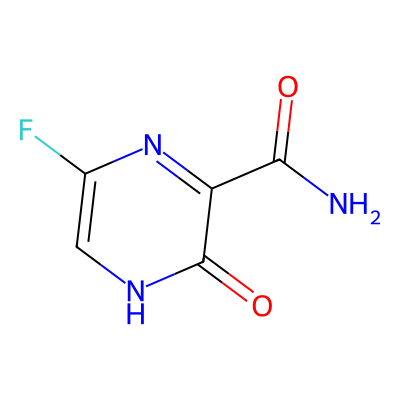

In [6]:
Draw.MolToImage(
    favipiravir,
    size=(400,400)
)

# Analog Design Strategy

A series of Favipiravir analogs were designed by modifying the substituent at the 6-position of the pyrazine ring. Both halogen substitutions and polar functional groups were explored to investigate their effects on molecular properties and protein binding.

Designed analogs:

- Fluoro (F)
- Chloro (Cl)
- Bromo (Br)
- Iodo (I)
- Methyl (CH3)
- Aminomethyl (CH2NH2)
- Hydroxyl (OH)
- Amino (NH2)

These modifications were selected to evaluate the influence of steric effects, electronic properties, hydrogen-bonding capability, and hydrophobicity on binding behavior.


In [7]:
analogs = {
    "Favipiravir-F": "F",
    "Favipiravir-Cl": "Cl",
    "Favipiravir-Br": "Br",
    "Favipiravir-I": "I",
    "Favipiravir-CH3": "C",
    "Favipiravir-CH2NH2": "CN",
    "Favipiravir-OH": "O",
    "Favipiravir-NH2": "N"
}

In [ ]:
molecules = {}

for name, group in analogs.items():

    smiles = favipiravir_smiles.replace(
        "F",
        group
    )

    mol = Chem.MolFromSmiles(smiles)

    molecules[name] = mol



# Visualization of Designed Analogs

The generated analogs are visualized to verify structural integrity and confirm successful substitution at the desired position of the Favipiravir scaffold.

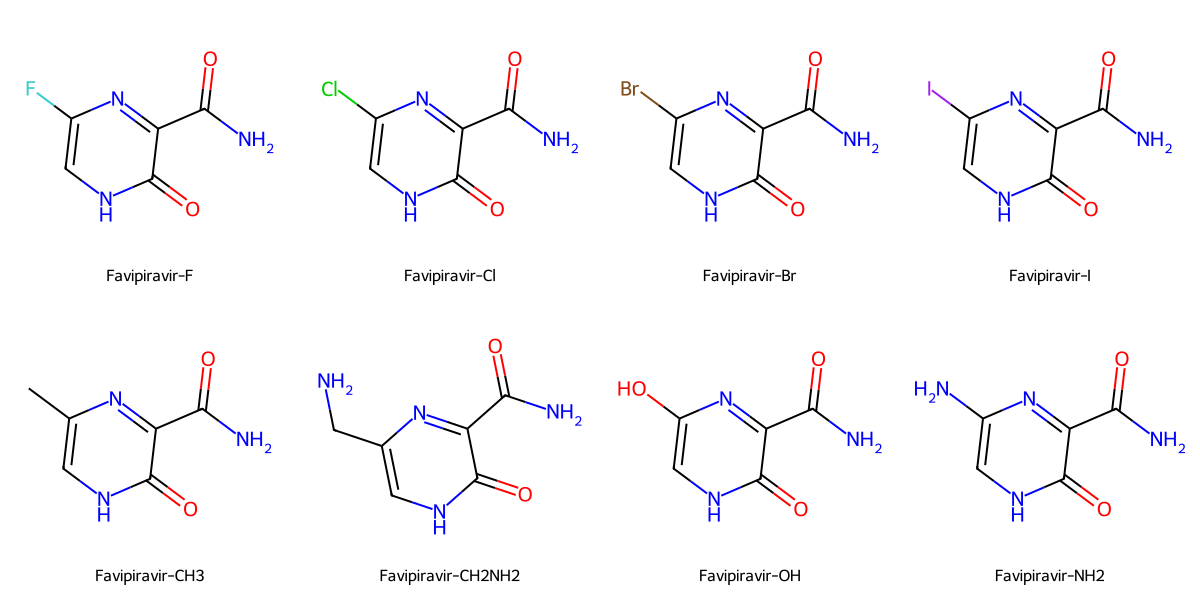

In [11]:
Draw.MolsToGridImage(
    list(molecules.values()),
    legends=list(molecules.keys()),
    molsPerRow=4,
    subImgSize=(300,300)
)

# Molecular Descriptor Calculation

Physicochemical descriptors were calculated for each analog to assess molecular properties relevant to drug discovery. These descriptors include:

- Molecular Weight (MW)
- LogP
- Hydrogen Bond Donors (HBD)
- Hydrogen Bond Acceptors (HBA)
- Topological Polar Surface Area (TPSA)
- Rotatable Bonds
- Ring Count
- Fraction of sp3 Carbon Atoms

These properties provide insight into molecular size, polarity, flexibility, and potential pharmacokinetic behavior.

In [12]:
results = []

for name, mol in molecules.items():

    mw = Descriptors.MolWt(mol)

    logp = Crippen.MolLogP(mol)

    hbd = Lipinski.NumHDonors(mol)

    hba = Lipinski.NumHAcceptors(mol)

    tpsa = rdMolDescriptors.CalcTPSA(mol)

    rot_bonds = Lipinski.NumRotatableBonds(mol)

    rings = Lipinski.RingCount(mol)

    fcsp3 = rdMolDescriptors.CalcFractionCSP3(mol)

    results.append([
        name,
        mw,
        logp,
        hbd,
        hba,
        tpsa,
        rot_bonds,
        rings,
        fcsp3
    ])

In [13]:
properties_df = pd.DataFrame(
    results,
    columns=[
        "Compound",
        "MW",
        "LogP",
        "HBD",
        "HBA",
        "TPSA",
        "Rotatable_Bonds",
        "Ring_Count",
        "Fraction_CSP3"
    ]
)

properties_df

,Compound,MW,LogP,HBD,HBA,TPSA,Rotatable_Bonds,Ring_Count,Fraction_CSP3
0,Favipiravir-F,157.104,-0.99210,2,3,88.84,1,1,0.000000
1,Favipiravir-Cl,173.559,-0.47780,2,3,88.84,1,1,0.000000
2,Favipiravir-Br,218.010,-0.36870,2,3,88.84,1,1,0.000000
3,Favipiravir-I,265.010,-0.52660,2,3,88.84,1,1,0.000000
4,Favipiravir-CH3,153.141,-0.82278,2,3,88.84,1,1,0.166667
5,Favipiravir-CH2NH2,168.156,-1.67250,3,4,114.86,2,1,0.166667
6,Favipiravir-OH,155.113,-1.42560,3,4,109.07,1,1,0.000000
7,Favipiravir-NH2,154.129,-1.54900,3,4,114.86,1,1,0.000000


# Lipinski Rule of Five Evaluation

Lipinski's Rule of Five is a widely used guideline for assessing oral drug-likeness. Compounds satisfying these criteria are generally more likely to exhibit favorable absorption and permeability characteristics.

Each designed analog was evaluated against the Lipinski criteria to identify potential violations.

In [14]:
def lipinski_pass(row):

    violations = 0

    if row["MW"] > 500:
        violations += 1

    if row["LogP"] > 5:
        violations += 1

    if row["HBD"] > 5:
        violations += 1

    if row["HBA"] > 10:
        violations += 1

    return violations <= 1

In [15]:
properties_df["Lipinski_Pass"] = properties_df.apply(
    lipinski_pass,
    axis=1
)

properties_df

,Compound,MW,LogP,HBD,HBA,TPSA,Rotatable_Bonds,Ring_Count,Fraction_CSP3,Lipinski_Pass
0,Favipiravir-F,157.104,-0.99210,2,3,88.84,1,1,0.000000,True
1,Favipiravir-Cl,173.559,-0.47780,2,3,88.84,1,1,0.000000,True
2,Favipiravir-Br,218.010,-0.36870,2,3,88.84,1,1,0.000000,True
3,Favipiravir-I,265.010,-0.52660,2,3,88.84,1,1,0.000000,True
4,Favipiravir-CH3,153.141,-0.82278,2,3,88.84,1,1,0.166667,True
5,Favipiravir-CH2NH2,168.156,-1.67250,3,4,114.86,2,1,0.166667,True
6,Favipiravir-OH,155.113,-1.42560,3,4,109.07,1,1,0.000000,True
7,Favipiravir-NH2,154.129,-1.54900,3,4,114.86,1,1,0.000000,True


# Quantitative Estimate of Drug-Likeness (QED)

The Quantitative Estimate of Drug-Likeness (QED) is a composite metric that summarizes multiple molecular properties into a single score ranging from 0 to 1.

Higher QED values indicate greater similarity to compounds commonly observed among approved drugs and clinical candidates.

In [16]:
from rdkit.Chem import QED

properties_df["QED"] = [
    QED.qed(mol)
    for mol in molecules.values()
]

properties_df

,Compound,MW,LogP,HBD,HBA,TPSA,Rotatable_Bonds,Ring_Count,Fraction_CSP3,Lipinski_Pass,QED
0,Favipiravir-F,157.104,-0.99210,2,3,88.84,1,1,0.000000,True,0.547935
1,Favipiravir-Cl,173.559,-0.47780,2,3,88.84,1,1,0.000000,True,0.601384
2,Favipiravir-Br,218.010,-0.36870,2,3,88.84,1,1,0.000000,True,0.673375
3,Favipiravir-I,265.010,-0.52660,2,3,88.84,1,1,0.000000,True,0.668960
4,Favipiravir-CH3,153.141,-0.82278,2,3,88.84,1,1,0.166667,True,0.551834
5,Favipiravir-CH2NH2,168.156,-1.67250,3,4,114.86,2,1,0.166667,True,0.489130
6,Favipiravir-OH,155.113,-1.42560,3,4,109.07,1,1,0.000000,True,0.461634
7,Favipiravir-NH2,154.129,-1.54900,3,4,114.86,1,1,0.000000,True,0.453795


# Synthetic Accessibility Analysis

Synthetic Accessibility (SA) scores were calculated to estimate the relative difficulty of chemical synthesis.

Lower SA scores indicate compounds that are generally easier to synthesize, whereas higher values suggest increased synthetic complexity. This metric provides practical insight into the feasibility of future experimental development.

In [17]:
!wget -q https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/sascorer.py
!wget -q https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/fpscores.pkl.gz

In [19]:
properties_df["SA_Score"] = [
    sascorer.calculateScore(mol)
    for mol in molecules.values()
]

properties_df

,Compound,MW,LogP,HBD,HBA,TPSA,Rotatable_Bonds,Ring_Count,Fraction_CSP3,Lipinski_Pass,QED,SA_Score
0,Favipiravir-F,157.104,-0.99210,2,3,88.84,1,1,0.000000,True,0.547935,2.897472
1,Favipiravir-Cl,173.559,-0.47780,2,3,88.84,1,1,0.000000,True,0.601384,2.913849
2,Favipiravir-Br,218.010,-0.36870,2,3,88.84,1,1,0.000000,True,0.673375,3.078265
3,Favipiravir-I,265.010,-0.52660,2,3,88.84,1,1,0.000000,True,0.668960,3.268354
4,Favipiravir-CH3,153.141,-0.82278,2,3,88.84,1,1,0.166667,True,0.551834,2.861124
5,Favipiravir-CH2NH2,168.156,-1.67250,3,4,114.86,2,1,0.166667,True,0.489130,2.955635
6,Favipiravir-OH,155.113,-1.42560,3,4,109.07,1,1,0.000000,True,0.461634,3.132442
7,Favipiravir-NH2,154.129,-1.54900,3,4,114.86,1,1,0.000000,True,0.453795,2.983600


# 3D Conformer Generation and Energy Minimization

Three-dimensional molecular conformations were generated using RDKit and subsequently optimized using the MMFF94 force field.

Energy minimization was performed to obtain low-energy conformers suitable for molecular docking studies and structural analysis.

In [22]:
optimized_molecules = {}
energy_results = []

for name, mol in molecules.items():

    mol_3d = Chem.AddHs(mol)

    status = AllChem.EmbedMolecule(
        mol_3d,
        randomSeed=42
    )

    if status != 0:
        print(f"Embedding failed: {name}")
        continue

    optimize_status = AllChem.MMFFOptimizeMolecule(mol_3d)

    props = AllChem.MMFFGetMoleculeProperties(mol_3d)

    ff = AllChem.MMFFGetMoleculeForceField(
        mol_3d,
        props
    )

    energy = ff.CalcEnergy()

    optimized_molecules[name] = mol_3d

    energy_results.append([
        name,
        optimize_status,
        energy
    ])

In [23]:
energy_df = pd.DataFrame(
    energy_results,
    columns=[
        "Compound",
        "Optimization_Status",
        "MMFF_Energy"
    ]
)

energy_df.sort_values("MMFF_Energy")

,Compound,Optimization_Status,MMFF_Energy
7,Favipiravir-NH2,0,15.178720
6,Favipiravir-OH,0,28.701551
0,Favipiravir-F,0,55.489235
1,Favipiravir-Cl,0,56.786803
2,Favipiravir-Br,0,57.781574
3,Favipiravir-I,0,58.565943
4,Favipiravir-CH3,0,63.737917
5,Favipiravir-CH2NH2,0,72.643376


### Export of Optimized Structures

The optimized three-dimensional conformers were exported in PDB format to enable visualization and downstream molecular modeling applications.

In [24]:
for name, mol in optimized_molecules.items():

    Chem.MolToPDBFile(
        mol,
        f"{name}.pdb"
    )

print("PDB export completed")

PDB export completed


# Integration of Molecular Properties

The calculated descriptors, drug-likeness metrics, and synthetic accessibility scores were consolidated into a single dataset to facilitate comparison across all designed analogs.

In [26]:
properties_df = properties_df.merge(
    energy_df[["Compound", "MMFF_Energy"]],
    on="Compound"
)

properties_df

,Compound,MW,LogP,HBD,HBA,TPSA,Rotatable_Bonds,Ring_Count,Fraction_CSP3,Lipinski_Pass,QED,SA_Score,MMFF_Energy
0,Favipiravir-F,157.104,-0.99210,2,3,88.84,1,1,0.000000,True,0.547935,2.897472,55.489235
1,Favipiravir-Cl,173.559,-0.47780,2,3,88.84,1,1,0.000000,True,0.601384,2.913849,56.786803
2,Favipiravir-Br,218.010,-0.36870,2,3,88.84,1,1,0.000000,True,0.673375,3.078265,57.781574
3,Favipiravir-I,265.010,-0.52660,2,3,88.84,1,1,0.000000,True,0.668960,3.268354,58.565943
4,Favipiravir-CH3,153.141,-0.82278,2,3,88.84,1,1,0.166667,True,0.551834,2.861124,63.737917
5,Favipiravir-CH2NH2,168.156,-1.67250,3,4,114.86,2,1,0.166667,True,0.489130,2.955635,72.643376
6,Favipiravir-OH,155.113,-1.42560,3,4,109.07,1,1,0.000000,True,0.461634,3.132442,28.701551
7,Favipiravir-NH2,154.129,-1.54900,3,4,114.86,1,1,0.000000,True,0.453795,2.983600,15.178720


# Retrieval of SARS-CoV-2 Main Protease Structure

The crystal structure of the SARS-CoV-2 main protease (Mpro) was obtained from the Protein Data Bank (PDB ID: 6LU7).

This protease plays a critical role in viral replication and has been extensively investigated as a therapeutic target for antiviral drug development.

In [50]:
!wget -q https://files.rcsb.org/download/6LU7.pdb

print("Downloaded 6LU7")

Downloaded 6LU7


In [29]:
!pip install biopython
from Bio.PDB import PDBParser

parser = PDBParser(QUIET=True)

structure = parser.get_structure(
    "6LU7",
    "6LU7.pdb"
)

print(structure)

<Structure id=6LU7>


# Structural Inspection of the Receptor

The receptor structure was inspected to identify protein chains, crystallographic water molecules, and co-crystallized ligands.

This step ensures proper receptor preparation prior to molecular docking.

In [30]:
from Bio.PDB import PDBParser

parser = PDBParser(QUIET=True)

structure = parser.get_structure(
    "6LU7",
    "6LU7.pdb"
)

for model in structure:
    for chain in model:
        print(
            "Chain",
            chain.id,
            "Residues:",
            len(list(chain))
        )

Chain A Residues: 390
Chain C Residues: 6


In [31]:
for model in structure:
    for chain in model:
        print(f"\nChain {chain.id}")

        for residue in chain:
            print(
                residue.get_resname(),
                residue.id
            )


Chain A
SER (' ', 1, ' ')
GLY (' ', 2, ' ')
PHE (' ', 3, ' ')
ARG (' ', 4, ' ')
LYS (' ', 5, ' ')
MET (' ', 6, ' ')
ALA (' ', 7, ' ')
PHE (' ', 8, ' ')
PRO (' ', 9, ' ')
SER (' ', 10, ' ')
GLY (' ', 11, ' ')
LYS (' ', 12, ' ')
VAL (' ', 13, ' ')
GLU (' ', 14, ' ')
GLY (' ', 15, ' ')
CYS (' ', 16, ' ')
MET (' ', 17, ' ')
VAL (' ', 18, ' ')
GLN (' ', 19, ' ')
VAL (' ', 20, ' ')
THR (' ', 21, ' ')
CYS (' ', 22, ' ')
GLY (' ', 23, ' ')
THR (' ', 24, ' ')
THR (' ', 25, ' ')
THR (' ', 26, ' ')
LEU (' ', 27, ' ')
ASN (' ', 28, ' ')
GLY (' ', 29, ' ')
LEU (' ', 30, ' ')
TRP (' ', 31, ' ')
LEU (' ', 32, ' ')
ASP (' ', 33, ' ')
ASP (' ', 34, ' ')
VAL (' ', 35, ' ')
VAL (' ', 36, ' ')
TYR (' ', 37, ' ')
CYS (' ', 38, ' ')
PRO (' ', 39, ' ')
ARG (' ', 40, ' ')
HIS (' ', 41, ' ')
VAL (' ', 42, ' ')
ILE (' ', 43, ' ')
CYS (' ', 44, ' ')
THR (' ', 45, ' ')
SER (' ', 46, ' ')
GLU (' ', 47, ' ')
ASP (' ', 48, ' ')
MET (' ', 49, ' ')
LEU (' ', 50, ' ')
ASN (' ', 51, ' ')
PRO (' ', 52, ' ')
ASN (' ', 53

# Binding Site Identification

The binding site was defined using the coordinates of the co-crystallized ligand present in the crystal structure.

Using the experimentally determined ligand position allows the docking search space to be centered on the biologically relevant active site and improves docking reliability.

In [32]:
for model in structure:
    for chain in model:

        if chain.id == "C":

            for residue in chain:

                coords = []

                for atom in residue:

                    coords.append(
                        atom.coord
                    )

                coords = np.array(coords)

                center = coords.mean(axis=0)

                print(
                    "Ligand:",
                    residue.get_resname()
                )

                print(
                    "Center:",
                    center
                )

Ligand: 02J
Center: [-10.464001   4.10375   73.00975 ]
Ligand: ALA
Center: [-12.745399   8.075399  71.8734  ]
Ligand: VAL
Center: [-10.741714  10.358285  68.95142 ]
Ligand: LEU
Center: [-12.1135    14.510501  70.485756]
Ligand: PJE
Center: [-11.575153  14.611616  65.1643  ]
Ligand: 010
Center: [-6.9643755 19.589376  66.85788  ]


In [33]:
import numpy as np

ligand_atoms = []

for model in structure:

    chain_c = model["C"]

    for residue in chain_c:

        for atom in residue:

            ligand_atoms.append(atom.coord)

ligand_atoms = np.array(ligand_atoms)

center = ligand_atoms.mean(axis=0)

print("Docking Center:")
print(center)

Docking Center:
[-10.729204  12.417654  68.816124]


In [34]:
mins = ligand_atoms.min(axis=0)
maxs = ligand_atoms.max(axis=0)

print("Minimum coordinates:")
print(mins)

print("\nMaximum coordinates:")
print(maxs)

print("\nBox size:")
print(maxs - mins)

Minimum coordinates:
[-14.397   1.458  63.232]

Maximum coordinates:
[-5.138 21.414 74.575]

Box size:
[ 9.259001  19.956     11.3429985]


# Receptor Preparation

The receptor was prepared by removing non-essential molecules and retaining the protein chain of interest.

The cleaned receptor structure was subsequently converted into PDBQT format for compatibility with AutoDock Vina.

In [35]:
from Bio.PDB import PDBIO, Select

class ProteinSelect(Select):

    def accept_chain(self, chain):

        return chain.id == "A"

    def accept_residue(self, residue):

        return residue.get_resname() != "HOH"


parser = PDBParser(QUIET=True)

structure = parser.get_structure(
    "6LU7",
    "6LU7.pdb"
)

io = PDBIO()

io.set_structure(structure)

io.save(
    "6LU7_clean.pdb",
    ProteinSelect()
)

print("Clean receptor saved")


Clean receptor saved


# Installation of Docking Dependencies

Additional molecular docking dependencies were installed, including Meeko and AutoDock Vina. These tools enable receptor preparation, ligand preparation, and docking calculations within the notebook environment.

In [65]:
!pip -q install meeko vina gemmi prody

# Conversion of Receptor to PDBQT Format

The prepared receptor structure was converted into PDBQT format, which contains atom types and partial charges required by AutoDock Vina for docking calculations.

In [42]:
!mk_prepare_receptor.py \
-i 6LU7_clean.pdb \
-o 6LU7_clean \
-p

@> 2367 atoms and 1 coordinate set(s) were parsed in 0.02s.

Files written:
6LU7_clean.pdbqt <-- static (i.e., rigid) receptor input file


# Ligand Preparation for Docking

The optimized analogs were exported as SDF files and converted into PDBQT format using Meeko. This preparation step assigns atom types, partial charges, and rotatable bond information required for AutoDock Vina docking simulations.

In [55]:
import os
from rdkit import Chem

os.makedirs("ligands_sdf", exist_ok=True)

for name, mol in optimized_molecules.items():

    writer = Chem.SDWriter(
        f"ligands_sdf/{name}.sdf"
    )

    writer.write(mol)
    writer.close()

print("SDF export complete")

SDF export complete


In [ ]:
import os
import glob

os.makedirs(
    "ligands_pdbqt",
    exist_ok=True
)

for sdf_file in glob.glob("ligands_sdf/*.sdf"):

    name = os.path.splitext(
        os.path.basename(sdf_file)
    )[0]

    output = (
        f"ligands_pdbqt/{name}.pdbqt"
    )

    !mk_prepare_ligand.py -i "$sdf_file" -o "$output"

print("All ligands converted")

# Docking Box Definition

The docking search space was derived from the coordinates of the co-crystallized ligand observed in the crystal structure.

Docking Center:

- X = -10.73
- Y = 12.42
- Z = 68.82

Docking Box Dimensions:

- Size X = 20 Å
- Size Y = 24 Å
- Size Z = 20 Å

This search space encompasses the active site region of SARS-CoV-2 main protease.

In [58]:
from vina import Vina

v = Vina(sf_name="vina")

v.set_receptor(
    "6LU7_clean.pdbqt"
)

v.compute_vina_maps(
    center=[
        -10.73,
        12.42,
        68.82
    ],
    box_size=[
        20,
        24,
        20
    ]
)

print("Maps generated successfully")

Maps generated successfully


# Molecular Docking Using AutoDock Vina

Molecular docking simulations were performed using AutoDock Vina to estimate the binding affinity of each designed analog toward SARS-CoV-2 main protease.

Docking Parameters:

- Exhaustiveness = 8
- Number of poses = 10

The lowest predicted binding energy for each compound was retained for further analysis.

In [60]:
import os
import pandas as pd

results = []

for ligand_file in sorted(os.listdir("ligands_pdbqt")):

    ligand_path = os.path.join(
        "ligands_pdbqt",
        ligand_file
    )

    v.set_ligand_from_file(
        ligand_path
    )

    v.dock(
        exhaustiveness=8,
        n_poses=10
    )

    best_score = float(
        v.energies()[0][0]
    )

    results.append([
        ligand_file.replace(".pdbqt",""),
        best_score
    ])

    print(
        ligand_file,
        best_score
    )

docking_df = pd.DataFrame(
    results,
    columns=[
        "Compound",
        "Docking_Affinity"
    ]
)

docking_df = docking_df.sort_values(
    "Docking_Affinity"
)

docking_df

Favipiravir-Br.pdbqt -4.852
Favipiravir-CH2NH2.pdbqt -5.313
Favipiravir-CH3.pdbqt -4.809
Favipiravir-Cl.pdbqt -4.84
Favipiravir-F.pdbqt -4.813
Favipiravir-I.pdbqt -4.834
Favipiravir-NH2.pdbqt -4.761
Favipiravir-OH.pdbqt -5.117


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Compound,Docking_Affinity
1,Favipiravir-CH2NH2,-5.313
7,Favipiravir-OH,-5.117
0,Favipiravir-Br,-4.852
3,Favipiravir-Cl,-4.840
5,Favipiravir-I,-4.834
4,Favipiravir-F,-4.813
2,Favipiravir-CH3,-4.809
6,Favipiravir-NH2,-4.761


# Consolidation of Docking and Molecular Properties

Docking results were merged with the previously calculated molecular descriptors, QED scores, and synthetic accessibility scores to enable comprehensive comparison among all analogs.

In [61]:
final_df = properties_df.merge(
    docking_df,
    on="Compound"
)

final_df = final_df.sort_values(
    "Docking_Affinity"
)

final_df

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Compound,MW,LogP,HBD,HBA,TPSA,Rotatable_Bonds,Ring_Count,Fraction_CSP3,Lipinski_Pass,QED,SA_Score,MMFF_Energy,Docking_Affinity
5,Favipiravir-CH2NH2,168.156,-1.67250,3,4,114.86,2,1,0.166667,True,0.489130,2.955635,72.643376,-5.313
6,Favipiravir-OH,155.113,-1.42560,3,4,109.07,1,1,0.000000,True,0.461634,3.132442,28.701551,-5.117
2,Favipiravir-Br,218.010,-0.36870,2,3,88.84,1,1,0.000000,True,0.673375,3.078265,57.781574,-4.852
1,Favipiravir-Cl,173.559,-0.47780,2,3,88.84,1,1,0.000000,True,0.601384,2.913849,56.786803,-4.840
3,Favipiravir-I,265.010,-0.52660,2,3,88.84,1,1,0.000000,True,0.668960,3.268354,58.565943,-4.834
0,Favipiravir-F,157.104,-0.99210,2,3,88.84,1,1,0.000000,True,0.547935,2.897472,55.489235,-4.813
4,Favipiravir-CH3,153.141,-0.82278,2,3,88.84,1,1,0.166667,True,0.551834,2.861124,63.737917,-4.809
7,Favipiravir-NH2,154.129,-1.54900,3,4,114.86,1,1,0.000000,True,0.453795,2.983600,15.178720,-4.761


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Multi-Parameter Lead Prioritization

A composite ranking score was calculated by combining docking affinity, drug-likeness (QED), and synthetic accessibility.

This ranking is exploratory in nature and is intended to provide a holistic comparison of candidate molecules. The resulting scores depend on the selected weighting scheme and should not be interpreted as definitive measures of therapeutic potential.

In [62]:
final_df["Docking_Norm"] = (
    final_df["Docking_Affinity"].abs()
    / final_df["Docking_Affinity"].abs().max()
)

final_df["QED_Norm"] = (
    final_df["QED"]
    / final_df["QED"].max()
)

final_df["SA_Norm"] = (
    1
    - (
        final_df["SA_Score"]
        / final_df["SA_Score"].max()
    )
)

final_df["Composite_Score"] = (
    0.5 * final_df["Docking_Norm"]
    + 0.3 * final_df["QED_Norm"]
    + 0.2 * final_df["SA_Norm"]
)

final_df = final_df.sort_values(
    "Composite_Score",
    ascending=False
)

final_df[
    [
        "Compound",
        "Docking_Affinity",
        "QED",
        "SA_Score",
        "Composite_Score"
    ]
]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Compound,Docking_Affinity,QED,SA_Score,Composite_Score
2,Favipiravir-Br,-4.852,0.673375,3.078265,0.768248
3,Favipiravir-I,-4.834,0.668960,3.268354,0.752955
1,Favipiravir-Cl,-4.840,0.601384,2.913849,0.745106
5,Favipiravir-CH2NH2,-5.313,0.489130,2.955635,0.737052
4,Favipiravir-CH3,-4.809,0.551834,2.861124,0.723340
0,Favipiravir-F,-4.813,0.547935,2.897472,0.719755
6,Favipiravir-OH,-5.117,0.461634,3.132442,0.695537
7,Favipiravir-NH2,-4.761,0.453795,2.983600,0.667650


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Conclusion

A series of Favipiravir analogs were successfully designed, evaluated, and screened against the SARS-CoV-2 main protease using a computational drug discovery workflow.

Among the designed analogs, the aminomethyl derivative (Favipiravir-CH2NH2) exhibited the strongest predicted binding affinity toward the target protein. Halogenated analogs, particularly brominated and iodinated derivatives, demonstrated favorable drug-likeness while maintaining competitive docking performance.

These findings suggest that both polar functionalization and halogen substitution represent promising strategies for further optimization of Favipiravir-derived antiviral candidates. Future work may include molecular dynamics simulations, ADMET prediction, and experimental validation of the identified lead compounds.